# Lesson 171 · Corpus of databases

**Skill:** produce an auditable corpus manifest and defend its holdout boundary. Tier B real relational data; synthetic examples only test failure modes. This portable notebook embeds the full small F1 archive and seven source definitions. It needs Python3, pandas and pyarrow; no RelBench installation, network or cloud execution. PROVIDED is scaffolding, TODO is your implementation, CHECK is feedback, EXIT is your written defense.

**Your task:** build a corpus manifest that lets another person reconstruct which databases could enter pretraining—and explain why a held-out database stayed out.

**Reading route.** Read §§1–4 for the core idea (about 20 minutes). Then inspect the measured audit and complete the notebook in a separate practice session. The optional full report exposes every table and key check.

**Recall first.** A database contains tables linked by keys. A *primary key* identifies a row within a table. A *foreign key* refers to a primary key in another table. A *query cutoff* is the moment at which a prediction must be made; information arriving later cannot support that prediction.

Recall without looking: why is a support draw not a new database? Which timestamp constrains a historical query?

## 1 · From a model design to a corpus contract

[Lesson 170](https://avistian.github.io/relational/lessons/0170-fm-design-checkpoint.html) asked you to defend a relational foundation-model design. It left a practical question open: **which databases is the model allowed to learn from?** A model can pass a prediction benchmark while having already seen the evaluation database during pretraining. The corpus contract must come before the first training batch.

A **corpus** is the collection of database snapshots selected for training. A **snapshot** is one recorded version of a database. A **manifest** is a machine-readable inventory of those versions and the rules governing their use. **Provenance** records where a snapshot came from and how it was transformed. It lets someone challenge a claim such as “this database was unseen.”

> **In plain terms.** A list of download URLs is a shopping list. A corpus manifest is a receipt plus an inclusion rule.

Our mission is to test whether relational learning adds value. An undocumented overlap between training and evaluation can make that value look larger than it is. [RelBench](https://arxiv.org/html/2407.20060v1) motivates evaluation across relational databases; [Griffin](https://arxiv.org/html/2505.05568v1) makes the pretraining collection consequential for transfer. This lesson builds the data contract, not a new predictor.

## 2 · Freeze identities before counting diversity

Use one record per database snapshot. Keep the database name, source-family identifiers, archive hash, source-code hash, declared table schema, time boundaries and audit scope together.

A **source family** groups versions or derivatives of the same underlying source. Renaming a copy of a racing database does not create a second independent domain. A **SHA256 hash** is a fingerprint of exact bytes: matching hashes identify byte-identical archives. Different hashes do *not* establish different underlying data; a re-export or small edit changes the hash.

| Manifest field | What it answers | What it does not establish |
|---|---|---|
| Database + source families | What identity and known ancestry were declared? | All undisclosed ancestry |
| Archive SHA256 | Are these the same bytes? | Independence when hashes differ |
| Source hash + schema | Which code declares tables, keys and times? | Whether unseen data obey those declarations |
| Time boundaries | What clocks and cutoff conventions are specified? | When a historical user could actually see a value |
| Row audit + rights review | What was checked and what remains? | Automatic permission or training eligibility |

**Our fixed scope.** The notebook pins the installed RelBench **1.1.0** source bytes for the seven original databases. This is an explicit historical release choice; the [current RelBench project](https://star-project.stanford.edu/relbench/) has expanded. We do not silently replace the lesson's corpus with today's registry.

The source-family field starts with one curator-declared family per original database. That is a usable inventory assumption, **not proof that all ancestry is known**. Record newly discovered shared sources and regenerate the split. Dataset usage rights remain `REVIEW_REQUIRED`: a software-package license does not by itself settle every source dataset's terms.

| Database | Declared tables | FK columns | Row evidence |
|---|---:|---:|---|
| rel-amazon | 3 | 2 | Source inventory only |
| rel-avito | 8 | 11 | Source inventory only |
| rel-event | 5 | 7 | Source inventory only |
| rel-f1 | 9 | 13 | Complete F1 snapshot |
| rel-hm | 3 | 2 | Source inventory only |
| rel-stack | 7 | 12 | Source inventory only |
| rel-trial | 15 | 15 | Source inventory only |

These are counts of **source-declared** tables and foreign-key columns. Only F1 receives the full row audit below. There is no claim that all seven archives were downloaded or that all seven are ready for training.

## 3 · Hold out a source family, not just a name

**Database-level holdout** means reserving a whole database for evaluation. A random row split within one database asks a different question: can the model predict additional rows from a familiar source? It cannot establish transfer to a new database.

**Worked example.** Suppose `race-original` is held out. `race-copy` has an identical archive hash. A third corpus shares a declared family with the copy, and a fourth shares a family with that third corpus. Excluding just the original name leaves three relatives in training.

Before reading on: should the tail corpus be excluded even though its hash differs from the held-out original? Write your prediction.

Treat each snapshot as a node. Link two nodes when their declared source families overlap or their archive hashes match. Starting at the held-out node, repeatedly follow links until no new node is reached. This set is its **connected component**. The held-out database stays in evaluation; its other component members go into **quarantine**, meaning excluded from training pending a provenance decision.

<figure class="route-figure" tabindex="0" style="overflow-x:auto">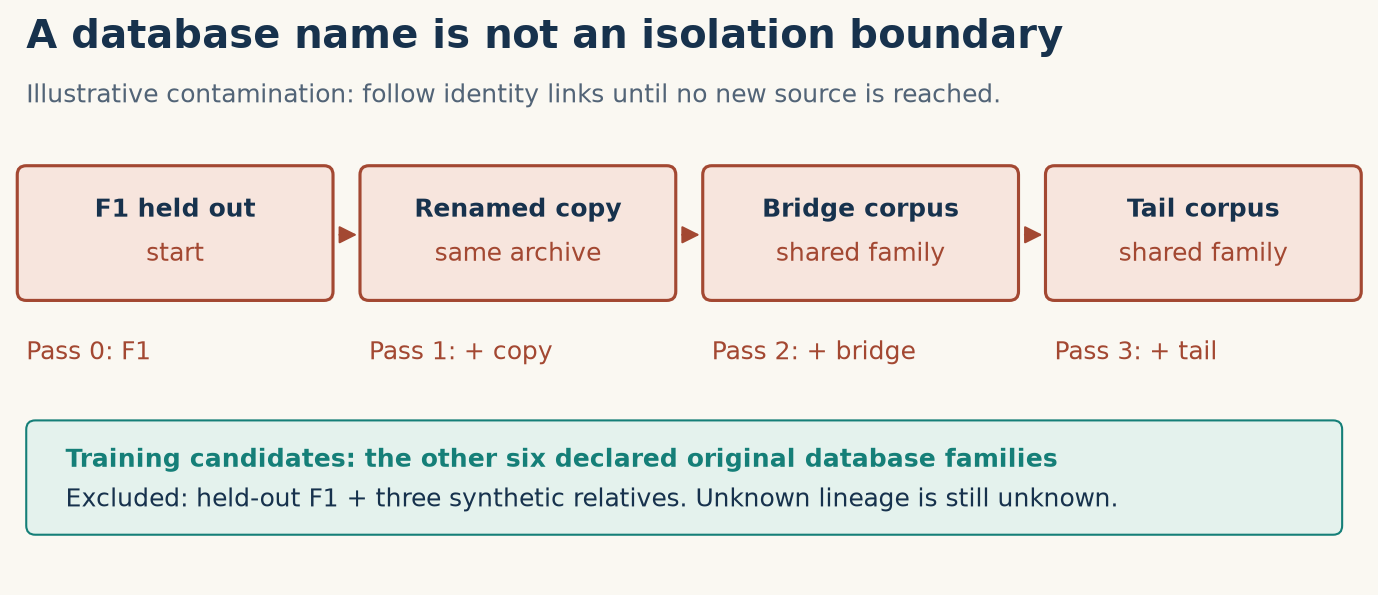<figcaption>Illustrative source-lineage chain. Starting with held-out F1, exclude its identical copy, then the bridge, then the tail. Six original declared families remain candidates. Synthetic additions are not actual RelBench contamination. Scroll horizontally on a narrow screen.</figcaption></figure>

The other component members need not contain the same rows. Quarantining the entire component is a deliberately conservative policy for source isolation; it may exclude more than a narrower row-overlap policy. It protects only against links represented in the manifest.

In the notebook, change the held-out database and compare the clean inventory with the synthetic copy/bridge/tail intervention. Six original candidates remain; three synthetic relatives are quarantined.

**Try it.** Choose each of the seven held-out databases. In the clean declared inventory, six remain training candidates. Turn on the clearly synthetic copy-and-bridge intervention. Three additional records must be quarantined, although two are not directly linked to the original. The baseline remains visible. None of these fictional records is evidence of contamination in actual RelBench.

The live TODO below implements the connected-component exclusion rule.

The notebook makes you implement the full validation and connected-component rule. Its final report calls your functions, including the deliberate alias cases; a hard-coded “six training databases” will fail.

## 4 · A valid relationship is not an available fact

A **referential-integrity audit** checks whether every non-null foreign key points to an existing primary key. An **orphan**, or dangling reference, points nowhere. Null foreign keys are counted separately: a missing optional relationship differs from a broken non-null relationship.

**Worked example.** Parent IDs are `[10, 20]`; child references are `[10, 10, null, 99]`. There are four rows, three non-null references, one missing reference and one dangling reference. The repeated `10` is valid: multiple child rows may refer to the same parent. Repeated *primary* keys would make row identity ambiguous.

<figure class="route-figure" tabindex="0" style="overflow-x:auto">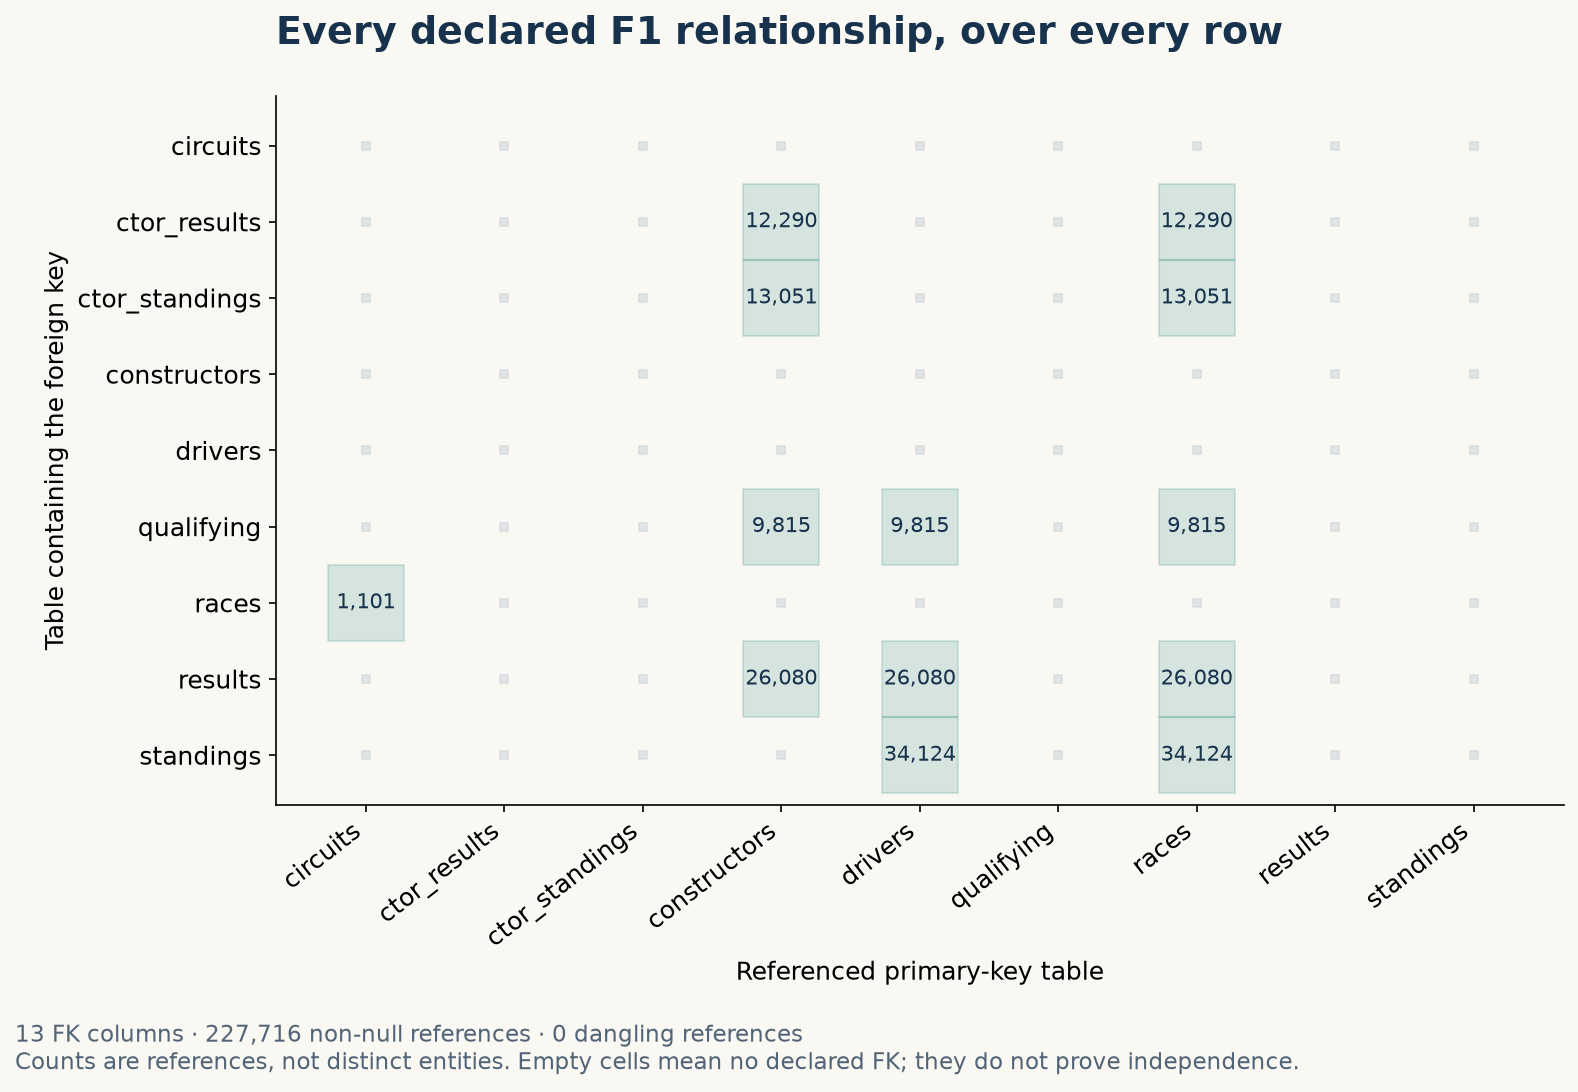<figcaption>Measured full F1 snapshot. Each filled cell counts non-null references from the row table to the column table. All 13 declared FK columns resolve; 227,716 references are not 227,716 distinct entities. Scroll horizontally on a narrow screen.</figcaption></figure>

**Measured scope.** We audit the complete cached F1 archive, matching its SHA256 to the pinned registry and matching every extracted table byte to the archive. We bypass the loader's time filtering for this audit so that nothing in the snapshot is silently omitted. Source-declared keys and Parquet metadata agree for all nine tables. The [pinned loader source](https://avistian.github.io/relational/labs/sources/l171/relbench/base/dataset.py) and [table source](https://avistian.github.io/relational/labs/sources/l171/relbench/base/table.py) expose filtering and metadata semantics.

| Table | Rows | PK nulls / duplicate excess | Time column |
|---|---:|---:|---|
| circuits | 77 | 0 / 0 | None |
| constructor_results | 12,290 | 0 / 0 | date |
| constructor_standings | 13,051 | 0 / 0 | date |
| constructors | 211 | 0 / 0 | None |
| drivers | 857 | 0 / 0 | None |
| qualifying | 9,815 | 0 / 0 | date |
| races | 1,101 | 0 / 0 | date |
| results | 26,080 | 0 / 0 | date |
| standings | 34,124 | 0 / 0 | date |

Across 227,716 non-null FK references: **0 dangling, 0 null FK values**. This is measured archive integrity; historical availability remains unestablished.

A clean key audit does not say a value was available at a prediction cutoff. **Event time** records when something happened. **Availability time** records when the information could be used. A later update to an old event can have an early event date. A static table without a time column has no row-level clock to prove historical availability.

<figure class="route-figure" tabindex="0" style="overflow-x:auto">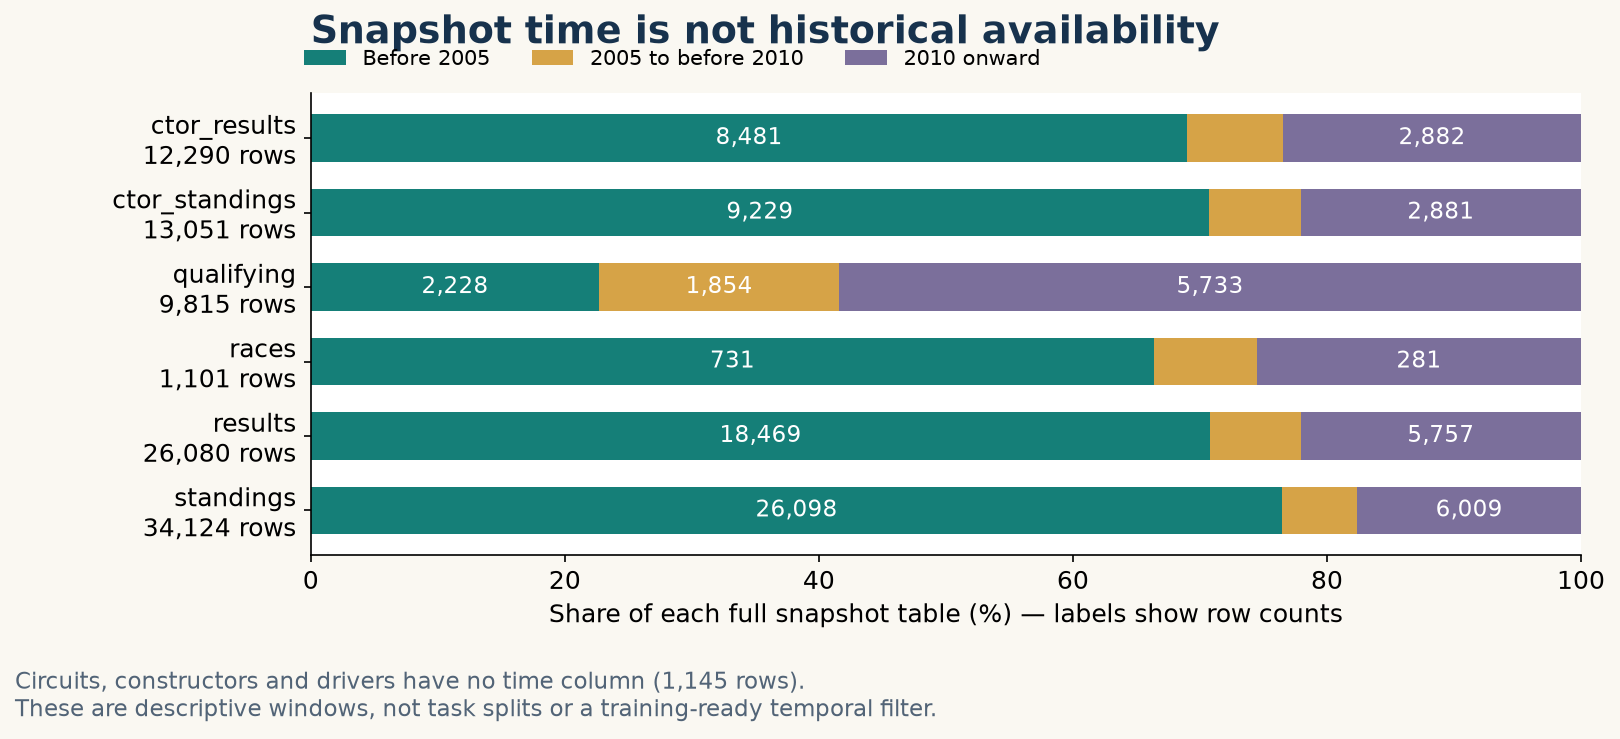<figcaption>Measured full F1 snapshot. Bars split each time-bearing table at 2005-01-01 and 2010-01-01. Labels show row counts. Three other tables lack time columns; event dates do not establish historical availability. Scroll horizontally on a narrow screen.</figcaption></figure>

The source defines F1 validation and test boundaries as **2005-01-01** and **2010-01-01**. Our descriptive windows are `date < 2005`, `2005 ≤ date < 2010`, and `date ≥ 2010`. These are snapshot row counts, **not task-label train/validation/test splits**. The full archive includes later records; that is expected for a stored snapshot, but feeding them to an earlier query would require an explicit information policy. The archive audit does not implement a point-in-time training sampler.

Circuits, constructors and drivers contribute **1,145 rows without a time column**. They stay in the inventory and retain `availability=NOT_ESTABLISHED`. Do not invent an old timestamp to make them pass. A later training pipeline must separately specify feature availability, label readiness and the cutoff propagated through joins.

## 5 · What the complete execution establishes

**Named execution:** L171 RelBench Corpus and Holdout Audit. Fixed: seven pinned source definitions and one complete F1 archive. Varied: which database is held out, plus clearly marked synthetic identity contamination. Measured: source inventory completeness, split membership, all F1 key checks and descriptive time counts. No model is fitted.

| Evidence | Status and precise meaning |
|---|---|
| Seven-source inventory | Complete for the declared release scope |
| Seven database holdouts | Pass for declared lineage; each clean split has six candidates |
| F1 snapshot | All 97,606 rows, nine tables and 13 FK columns audited |
| Other six row audits | `NOT_RUN`; source declarations are not observed rows |
| Historical identity and availability | `NOT_ESTABLISHED` |
| Foundation-model pretraining / whole-paper reproduction | `NOT_RUN` |
| Transfer advantage | `NOT_ESTABLISHED`; no predictive experiment here |
| Learner defense | `PENDING_WRITTEN_DEFENSE` |

This is the **complete approved corpus audit**, not a reproduction of a paper's training result. “Complete” names the finite audited scope. It does not expand the evidence to missing databases, hidden lineage or downstream accuracy.

**Compute contract:** $0 new cloud/API spend; 1,800-second aggregate local audit/check/notebook limit, including failed attempts. The command wrapper stops at the limit and retains the attempt ledger. Browser, authoring and publication-build work are separate delivery checks. [Protocol and exact commands](https://avistian.github.io/relational/labs/l171-reproduction.md) · [Corpus manifest](https://avistian.github.io/relational/labs/evidence/l171/corpus-manifest.json) · [Full report](https://avistian.github.io/relational/labs/evidence/l171/report.json).

## 6 · Lab: make the corpus contract executable

[Student notebook](https://avistian.github.io/relational/labs/0171-corpus-of-databases.ipynb) · [Prepared notebook with reference outputs](https://avistian.github.io/relational/labs/html/0171-corpus-of-databases.html) · [Quick reference](https://avistian.github.io/relational/reference/corpus-of-databases.html).

1. Validate the manifest: reject missing lineage declarations, malformed hashes and duplicate database identities.
2. Implement source-family/identical-archive exclusion, including the two-hop bridge.
3. Audit the full F1 snapshot: primary-key nulls and duplicates, foreign-key orphans and nulls, and time windows. Independent checks challenge the same functions used in your final report.
4. Write a corpus card naming an evaluation holdout, training candidates, quarantined relatives, unverified lineage and the next evidence needed before pretraining.

The portable notebook includes exact source snapshots and the complete small F1 archive. It recomputes the report from those bytes. Synthetic checks isolate errors; they never stand in for real rows. PROVIDED means run the supplied scaffolding; TODO means implement the named behavior; CHECK gives immediate feedback; EXIT asks for your interpretation.

**Exit standard:** code checks pass and your defense explains (a) why different archive hashes cannot prove source independence, (b) why the bridge is quarantined, and (c) why clean foreign keys cannot establish historical availability. Submit the corpus card and report for teacher review. Execution alone does not establish learner mastery.

Write your defense before reading a reference outline. Explain why clean keys cannot certify historical availability. Ask the teacher to review it.

**Next:** [Lesson 172](https://avistian.github.io/relational/lessons/0172-schema-tokenization.html) turns table and column declarations into schema tokens. Keep corpus identity separate from token identity: changing a database's token spelling must not create a new held-out source.

**Primary reading:** [RelBench, Robinson et al., 2024](https://arxiv.org/html/2407.20060v1), the benchmark construction and dataset descriptions. Read alongside the pinned source inventory rather than borrowing unverified dataset counts from a different release. Ask the teacher any follow-up question, especially about an exclusion you think is too conservative.


In [1]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import base64,hashlib,io,json,zipfile
from pathlib import Path
try:
    import pandas as pd
    import pyarrow.parquet as pq
except ImportError as exc:
    raise RuntimeError("Install pandas==3.0.3 and pyarrow==24.0.0, then rerun this cell") from exc
P=Path("l171-portable");P.mkdir(exist_ok=True)

## PROVIDED · Authenticate exact evidence bytes
The payload holds the nine complete F1 tables, their archive and pinned source definitions. The input manifest records each file hash. This does not authenticate historical paper identity or hidden lineage. Data payload is hidden only in prepared HTML for readability; it remains in this notebook.

In [2]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='fa3f6fec99a8ce467639405c5baae682019f240236b67fb40712fdbdc1446c4d'
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for name in archive.namelist():
        assert not Path(name).is_absolute() and ".." not in Path(name).parts
    archive.extractall(P)
manifest={'experiment': 'L171 RelBench Corpus and Holdout Audit', 'files': {'sources/l171/LICENSE': '373b7c4e5ab541b3a753e1cff5643f494bbc2f6f6917d8fbd225de8ea7dbf3fc', 'sources/l171/METADATA': '4db7ae34d81b62ca195bcbaa3d625d9b7ffd839f1e2f2049d54fdca7d635f392', 'sources/l171/relbench/base/database.py': '8f5ac171e4a3d01ef345e55c30fac764831cf3acb2eb4a47b383d615563e73bd', 'sources/l171/relbench/base/dataset.py': '9552c4c72dbc333d652d89a25542d6ae5f6d2756febc050886c9c5f3b6827c14', 'sources/l171/relbench/base/table.py': '4cb619601ef2c8d2b4180c3e881fe7d64e8763123c8fbfe84fd2663dd371b81f', 'sources/l171/relbench/datasets/__init__.py': '2f8abaf3d09fe439483d8f634e5486414f300b37a2d0f319e5ca76d58747c061', 'sources/l171/relbench/datasets/amazon.py': '4980a9b505f21ad71ef8cfb27d69d8d466a8b51b47e02dbe3d7acd70a5399549', 'sources/l171/relbench/datasets/avito.py': 'cfba15fdd0065a1040d367513c8a7532e31db0fc324a8852a63b875cb79e590e', 'sources/l171/relbench/datasets/event.py': 'acaf3be503338b17ff36b5b0274c0964582c9bbef9587f10146bb6763975518b', 'sources/l171/relbench/datasets/f1.py': '51608a63a55d2f198558fc4dda87ecc59cd089a26fa94dc94b50cccade3fad84', 'sources/l171/relbench/datasets/hashes.json': '66d9fb2582c9ff2a7a8d801227dfb8f5d339ebf47973d526b30d32ce013fbbeb', 'sources/l171/relbench/datasets/hm.py': 'd6ac27ff2358806c7e2d10fc3ae74e0fee59d494dde08270da61087a5bbf507c', 'sources/l171/relbench/datasets/stack.py': 'a1104d759cce06b838a2a51c16b5afffb5bebddcace2786d4d303b09ceff4ee3', 'sources/l171/relbench/datasets/trial.py': 'a8e84057b7775332f2a03095825fc205bf0529a56c492ae67630578b3d76003f', 'sources/l171/relbench-current.html': 'd3607b6b1561e6cccc12a05a7f9740dc058def8dafaeb93b99c2ad5a28f9f3cf', 'sources/l171/relbench-paper.html': 'f933604d45fa863819902b13f5b65f7ea684c7f9f9b74a61f2229c7c2f73f1fc', 'sources/l171/source-ledger.json': 'f1de5a931ed98d57bd4d8535dd8dc7549c8464e0f5ac089823892d14dc006aec', 'evidence/l171/db/circuits.parquet': 'c36c6537b9c5c9985ec438110717e93289085a5bffbcee07d08bbe1771994d8d', 'evidence/l171/db/constructor_results.parquet': '35582c2f0634d5503b664babf38264311332e6ca3cb612fb0fe737bfaffdc29e', 'evidence/l171/db/constructor_standings.parquet': '739fc21ba301ef2081dbd8e56d643f148b672224a4d223b95d6107ccd735aa6b', 'evidence/l171/db/constructors.parquet': 'fc79dd346430186cdca6263e1c532891bf4d4ba7463fd94b398350a9356180c6', 'evidence/l171/db/drivers.parquet': 'ba3461b83a1a467a856bde4059519140a5a31952ad24a5e944ea9dd5c5faceae', 'evidence/l171/db/qualifying.parquet': '2d5cb7b4ed6cf4076b74ab1cc79f5f35faf31b7f032b51d2a1ac814e1d0c834b', 'evidence/l171/db/races.parquet': '88bb260f03c9ec5c7b030969d7284531d5f8e8592d73174686ad01cdfc8f87ea', 'evidence/l171/db/results.parquet': 'b8b0e39b27f318a7bd461f21bb0ba9ef44909ed569d287e0c6b2969c6bd2f598', 'evidence/l171/db/standings.parquet': 'f3f6a34fee190f077f2fe48026a7e5659e4c91a34f72340cdff3cf407c1f3534', 'evidence/l171/rel-f1-db.zip': 'ec31a4e1bc2b2f9c36c05fcd3dfe2a40a506f335dc51ce79c3ec8bb40feb1482'}}
print("Exact source and complete F1 archive packet authenticated")

Exact source and complete F1 archive packet authenticated


## TODO · Freeze valid records

**Why:** this operation controls the final real-data audit. The CHECK is deliberately small; a broader suite follows.

**Contract:** Accept a nonempty list of record dictionaries. Require unique nonempty database strings, a nonempty list of distinct nonempty source-family strings, and a lowercase 64-character hexadecimal archive SHA256. Raise ValueError on violations. Return an independent deep copy sorted by database, with each source-family list sorted; retain additional fields unchanged. Do not modify the caller's records.

In [3]:
def validate_corpus(records):
    """Validate declared identities and return a deterministic, independent copy."""
    import copy
    import re
    if not isinstance(records, list) or not records:
        raise ValueError('A nonempty list of records is required')
    result = copy.deepcopy(records)
    names = set()
    for row in result:
        name = row.get('database')
        families = row.get('source_families')
        digest = row.get('archive_sha256')
        if not isinstance(name, str) or not name.strip() or name in names:
            raise ValueError('Database names must be nonempty and unique')
        if (not isinstance(families, list) or not families
                or any(not isinstance(x, str) or not x.strip() for x in families)
                or len(families) != len(set(families))):
            raise ValueError('Declare distinct, nonempty source-family identifiers')
        if not isinstance(digest, str) or not re.fullmatch('[0-9a-f]{64}', digest):
            raise ValueError('Expected lowercase SHA256 archive digest')
        names.add(name)
        row['source_families'] = sorted(families)
    return sorted(result, key=lambda row: row['database'])

In [4]:
# CHECK
demo=[dict(database="z",source_families=["origin-z"],archive_sha256="a"*64),dict(database="a",source_families=["origin-a"],archive_sha256="b"*64)]
assert [r["database"] for r in validate_corpus(demo)]==["a","z"]
assert demo[0]["database"]=="z"
print("CHECK: deterministic inventory, original untouched")

CHECK: deterministic inventory, original untouched


## TODO · Exclude the connected source family

**Why:** this operation controls the final real-data audit. The CHECK is deliberately small; a broader suite follows.

**Contract:** Call validate_corpus. Reject an unknown heldout name with ValueError. Link records when any source-family identifier matches OR the archive hashes match. Follow links transitively. Return train (sorted unconnected names), heldout (the single requested name), quarantine (sorted connected names except the requested one). This is a conservative declared-lineage rule, not a claim that all connected records contain the same rows.

In [5]:
def split_corpus(records, heldout):
    """Exclude the entire connected lineage component of the held-out database."""
    rows = validate_corpus(records)
    names = {row['database'] for row in rows}
    if heldout not in names:
        raise ValueError('Held-out database is absent')
    excluded = {heldout}
    # Fixed point: a bridge may connect a second-hop alias to the held-out source.
    while True:
        families = {f for row in rows if row['database'] in excluded
                    for f in row['source_families']}
        archives = {row['archive_sha256'] for row in rows
                    if row['database'] in excluded}
        expanded = excluded | {row['database'] for row in rows
                               if families.intersection(row['source_families'])
                               or row['archive_sha256'] in archives}
        if expanded == excluded:
            break
        excluded = expanded
    return dict(train=sorted(names - excluded), heldout=[heldout],
                quarantine=sorted(excluded - {heldout}))

In [6]:
# CHECK
example=[dict(database=n,source_families=f,archive_sha256=h*64) for n,f,h in [("a",["x"],"a"),("b",["x","y"],"b"),("c",["y"],"c"),("d",["z"],"d")]]
assert split_corpus(example,"a")==dict(train=["d"],heldout=["a"],quarantine=["b","c"])
print("CHECK: transitive bridge excluded")

CHECK: transitive bridge excluded


## TODO · Audit every declared row relationship

**Why:** this operation controls the final real-data audit. The CHECK is deliberately small; a broader suite follows.

**Contract:** Input maps table names to df (pandas DataFrame), pkey_col, time_col and fkey_col_to_pkey_table. Also accept ordered finite validation and test timestamp strings. Reject empty tables, reversed/invalid boundaries and missing declared columns or FK targets with ValueError.

Return tables (sorted name to stats), foreign_keys (sorted table/column order), rows (sum), foreign_key_columns (count), integrity (PASS unless PK nulls/duplicates or dangling FKs), availability (always NOT_ESTABLISHED). Per-table stats: rows, columns, pkey, pk_nulls, pk_duplicate_excess (repetitions beyond the first non-null key), time_col. With no PK both PK counts are None. With no clock set time_status=NO_TIME_COLUMN, time_windows=None. Otherwise use time_status=OBSERVED_EVENT_TIME; time_min/time_max are string timestamps or None; time_windows has before_val, val_to_test, at_or_after_test, nulls. Use <val, [val,test), >=test. Each FK entry: table,column,target,rows,nulls,dangling,nonnull. Null FKs alone do not fail integrity. Do not remove any rows.

In [7]:
def audit_tables(tables, val_timestamp, test_timestamp):
    """Count full-snapshot PK/FK defects and time windows, without filtering rows."""
    import pandas as pd
    val, test = pd.Timestamp(val_timestamp), pd.Timestamp(test_timestamp)
    if pd.isna(val) or pd.isna(test) or val >= test or not tables:
        raise ValueError('Require tables and ordered finite time boundaries')
    result = dict(tables={}, foreign_keys=[], rows=0, foreign_key_columns=0,
                  integrity='PASS', availability='NOT_ESTABLISHED')
    for name in sorted(tables):
        table = tables[name]
        frame, pk, time = table['df'], table['pkey_col'], table['time_col']
        columns = [x for x in [pk, time] if x is not None]
        columns += list(table['fkey_col_to_pkey_table'])
        if any(x not in frame for x in columns):
            raise ValueError('Declared column missing from '+name)
        nulls = int(frame[pk].isna().sum()) if pk else None
        duplicates = int(frame.loc[frame[pk].notna(), pk].duplicated().sum()) if pk else None
        row = dict(rows=len(frame), columns=len(frame.columns), pkey=pk,
                   pk_nulls=nulls, pk_duplicate_excess=duplicates, time_col=time)
        if time is None:
            row.update(time_status='NO_TIME_COLUMN', time_windows=None)
        else:
            values = pd.to_datetime(frame[time], errors='raise')
            row.update(time_status='OBSERVED_EVENT_TIME',
                       time_min=None if not values.notna().any() else str(values.min()),
                       time_max=None if not values.notna().any() else str(values.max()),
                       time_windows=dict(before_val=int((values < val).sum()),
                           val_to_test=int(((values >= val) & (values < test)).sum()),
                           at_or_after_test=int((values >= test).sum()),
                           nulls=int(values.isna().sum())))
        result['tables'][name] = row
        result['rows'] += len(frame)
        if nulls or duplicates:
            result['integrity'] = 'FAIL'
        for column, target in sorted(table['fkey_col_to_pkey_table'].items()):
            if target not in tables or tables[target]['pkey_col'] is None:
                raise ValueError('Foreign key target absent or has no primary key')
            parent = tables[target]
            if parent['pkey_col'] not in parent['df']:
                raise ValueError('Target primary key column missing')
            values = frame[column]
            nonnull = values.notna()
            keys = parent['df'][parent['pkey_col']].dropna()
            dangling = int((nonnull & ~values.isin(keys)).sum())
            result['foreign_keys'].append(dict(table=name, column=column,
                target=target, rows=len(frame), nulls=int((~nonnull).sum()),
                dangling=dangling, nonnull=int(nonnull.sum())))
            if dangling:
                result['integrity'] = 'FAIL'
    result['foreign_key_columns'] = len(result['foreign_keys'])
    return result

In [8]:
# CHECK
import pandas as pd
example={"p":dict(df=pd.DataFrame({"id":[10,20]}),pkey_col="id",time_col=None,fkey_col_to_pkey_table={}),"c":dict(df=pd.DataFrame({"parent":[10,10,None,99]}),pkey_col=None,time_col=None,fkey_col_to_pkey_table={"parent":"p"})}
observed=audit_tables(example,"2005-01-01","2010-01-01")
assert observed["foreign_keys"][0]["nulls"]==1
assert observed["foreign_keys"][0]["dangling"]==1
assert observed["integrity"]=="FAIL" and observed["availability"]=="NOT_ESTABLISHED"
print("CHECK: null references are not dangling references")

CHECK: null references are not dangling references


## CHECK · Challenge the live functions
These checks reject invalid manifests, renamed copies, transitive overlap, orphan references, duplicate and missing primary keys, absent targets and reversed time bounds. They call the functions you just wrote.

In [9]:
def check171(validate_corpus, split_corpus, audit_tables):
    import copy
    import pandas as pd
    def record(name, families, digest):
        return dict(database=name, source_families=families, archive_sha256=digest*64)
    records=[record('a',['alpha'],'a'),record('b',['beta'],'b'),record('c',['gamma'],'c')]
    assert [x['database'] for x in validate_corpus(list(reversed(records)))]==['a','b','c']
    def rejects(fn, *args):
        try: fn(*args)
        except ValueError: return
        raise AssertionError('invalid input accepted')
    rejects(validate_corpus,records+[records[0]])
    for field,value in [('database',''),('source_families',[]),('source_families',['']),('archive_sha256','wrong')]:
        bad=copy.deepcopy(records);bad[0][field]=value;rejects(validate_corpus,bad)
    assert split_corpus(records,'a')==dict(train=['b','c'],heldout=['a'],quarantine=[])
    # Alias and transitive bridge: name-only or direct-neighbor checks must fail.
    linked=copy.deepcopy(records);linked[1]['source_families']=['alpha','bridge'];linked[2]['source_families']=['bridge']
    assert split_corpus(linked,'a')==dict(train=[],heldout=['a'],quarantine=['b','c'])
    duplicate=copy.deepcopy(records);duplicate[2]['archive_sha256']=duplicate[0]['archive_sha256']
    assert split_corpus(duplicate,'a')['quarantine']==['c']
    rejects(split_corpus,records,'missing')
    tables={
      'parents':dict(df=pd.DataFrame({'id':[1,2]}),pkey_col='id',fkey_col_to_pkey_table={},time_col=None),
      'children':dict(df=pd.DataFrame({'id':[10,11,12,13], 'parent':[1,1,None,9], 'date':pd.to_datetime(['2000-01-01','2005-01-01','2010-01-01',None])}),pkey_col='id',fkey_col_to_pkey_table={'parent':'parents'},time_col='date')}
    report=audit_tables(tables,'2005-01-01','2010-01-01')
    assert report['rows']==6 and report['foreign_key_columns']==1
    assert report['foreign_keys'][0]==dict(table='children',column='parent',target='parents',rows=4,nulls=1,dangling=1,nonnull=3)
    assert report['tables']['children']['time_windows']==dict(before_val=1,val_to_test=1,at_or_after_test=1,nulls=1)
    assert report['tables']['parents']['time_status']=='NO_TIME_COLUMN'
    assert report['integrity']=='FAIL' and report['availability']=='NOT_ESTABLISHED'
    clean=copy.deepcopy(tables);clean['children']['df'].loc[3,'parent']=2
    assert audit_tables(clean,'2005-01-01','2010-01-01')['integrity']=='PASS'
    for values in [[1,1],[1,None]]:
        bad=copy.deepcopy(clean);bad['parents']['df']['id']=values
        assert audit_tables(bad,'2005-01-01','2010-01-01')['integrity']=='FAIL'
    bad=copy.deepcopy(clean);bad['children']['fkey_col_to_pkey_table']['parent']='absent'
    rejects(audit_tables,bad,'2005-01-01','2010-01-01')
    rejects(audit_tables,clean,'2010-01-01','2005-01-01')
    return 'PASS'

In [10]:
assert check171(validate_corpus,split_corpus,audit_tables)=="PASS"
print("Live corpus contracts PASS")

Live corpus contracts PASS


## PROVIDED · Read source declarations without executing source code
This visible scaffolding calls your validation, split and audit functions. It retains source-only evidence separately from observed row checks.

In [11]:
def source_inventory(root, validate):
    import ast
    import hashlib
    import json
    import re
    from pathlib import Path
    root=Path(root); base=root/'sources/l171/relbench/datasets'
    hashes=json.loads((base/'hashes.json').read_text())
    records=[]
    for short in ['amazon','avito','event','f1','hm','stack','trial']:
        path=base/(short+'.py'); text=path.read_text();tree=ast.parse(text)
        schema={};boundaries={}
        def table_call(node):
            return isinstance(node,ast.Call) and isinstance(node.func,ast.Name) and node.func.id=='Table'
        def add(name,call):
            if name in schema:raise ValueError('Ambiguous table definition')
            fields={k.arg:ast.literal_eval(k.value) for k in call.keywords if k.arg in ['pkey_col','time_col','fkey_col_to_pkey_table']}
            schema[name]=dict(pkey_col=fields.get('pkey_col'),time_col=fields.get('time_col'),fkey_col_to_pkey_table=fields.get('fkey_col_to_pkey_table',{}))
        for node in ast.walk(tree):
            if isinstance(node,ast.Assign):
                for target in node.targets:
                    if isinstance(target,ast.Name) and target.id in ['val_timestamp','test_timestamp']:
                        boundaries[target.id]=ast.literal_eval(node.value.args[0])
                    if isinstance(target,ast.Subscript) and table_call(node.value):
                        add(ast.literal_eval(target.slice),node.value)
            if isinstance(node,ast.Dict):
                for key,value in zip(node.keys,node.values):
                    if table_call(value):add(ast.literal_eval(key),value)
        calls=sum(table_call(n) for n in ast.walk(tree))
        if not schema or len(schema)!=calls or len(boundaries)!=2:
            raise ValueError('Incomplete static extraction: '+short)
        for spec in schema.values():
            if not set(spec['fkey_col_to_pkey_table'].values())<=set(schema):
                raise ValueError('Declared FK table absent: '+short)
        database='rel-'+short
        records.append(dict(database=database,source_families=['declared-original:'+short],
            family_evidence='CURATOR_DECLARATION_NOT_EXHAUSTIVE_LINEAGE',
            archive_sha256=hashes[database+'/db.zip'],
            source_sha256=hashlib.sha256(path.read_bytes()).hexdigest(),
            source_path=str(path.relative_to(root)),
            upstream_urls=sorted(set(re.findall(r'https?://[^\s\"\'<>]+',text))),
            tables=dict(sorted(schema.items())),**boundaries,
            row_audit='FULL_SNAPSHOT' if short=='f1' else 'NOT_RUN',
            rights='REVIEW_REQUIRED',historical_availability='NOT_ESTABLISHED'))
    return validate(records)

## PROVIDED · Read every actual F1 table and its key metadata
This visible scaffolding calls your validation, split and audit functions. It retains source-only evidence separately from observed row checks.

In [12]:
def load_f1(root):
    import json
    from pathlib import Path
    import pyarrow.parquet as pq
    result={}
    for path in sorted((Path(root)/'evidence/l171/db').glob('*.parquet')):
        table=pq.read_table(path)
        spec={name:json.loads(table.schema.metadata[name.encode()]) for name in ['pkey_col','time_col','fkey_col_to_pkey_table']}
        result[path.stem]=dict(df=table.to_pandas(),**spec)
    return result

## PROVIDED · Authenticate, join the declared schema to actual rows, and run the complete audit
This visible scaffolding calls your validation, split and audit functions. It retains source-only evidence separately from observed row checks.

In [13]:
def replay171(root, manifest, validate, split, audit):
    import copy
    import hashlib
    import json
    import zipfile
    from pathlib import Path
    root=Path(root)
    for name,digest in manifest['files'].items():
        path=Path(name)
        if path.is_absolute() or '..' in path.parts:raise ValueError('Unsafe manifest path')
        if hashlib.sha256((root/path).read_bytes()).hexdigest()!=digest:raise ValueError('Input hash mismatch: '+name)
    inventory=source_inventory(root,validate)
    f1=next(r for r in inventory if r['database']=='rel-f1')
    archive=root/'evidence/l171/rel-f1-db.zip'
    if hashlib.sha256(archive.read_bytes()).hexdigest()!=f1['archive_sha256']:raise ValueError('Archive/registry mismatch')
    tables=load_f1(root)
    if set(tables)!=set(f1['tables']):raise ValueError('Incomplete F1 table set')
    with zipfile.ZipFile(archive) as z:
        names={n for n in z.namelist() if n.endswith('.parquet')}
        if names!={'db/'+n+'.parquet' for n in tables}:raise ValueError('Archive population mismatch')
        for name,spec in tables.items():
            if z.read('db/'+name+'.parquet')!=(root/'evidence/l171/db'/(name+'.parquet')).read_bytes():raise ValueError('Archive member mismatch')
            if {k:spec[k] for k in f1['tables'][name]}!=f1['tables'][name]:raise ValueError('Source/parquet schema mismatch')
    row_audit=audit(tables,f1['val_timestamp'],f1['test_timestamp'])
    splits={row['database']:split(inventory,row['database']) for row in inventory}
    # Deliberately synthetic aliases and a two-hop bridge, never real source claims.
    contaminated=copy.deepcopy(inventory)
    alias=copy.deepcopy(f1);alias.update(database='synthetic-f1-copy',source_families=['synthetic-copy'])
    bridge=copy.deepcopy(inventory[0]);bridge.update(database='synthetic-bridge',source_families=['synthetic-copy','synthetic-tail'],archive_sha256='1'*64)
    tail=copy.deepcopy(inventory[0]);tail.update(database='synthetic-tail',source_families=['synthetic-tail'],archive_sha256='2'*64)
    contaminated.extend([alias,bridge,tail])
    return dict(experiment=manifest['experiment'],status='COMPLETE_DECLARED_CORPUS_AUDIT',
        inventory=inventory,splits=splits,contamination_demo=split(contaminated,'rel-f1'),
        full_snapshot=row_audit,inventory_databases=len(inventory),
        declared_tables=sum(len(r['tables']) for r in inventory),
        declared_foreign_key_columns=sum(len(s['fkey_col_to_pkey_table']) for r in inventory for s in r['tables'].values()),
        inventory_validation='PASS',split_validation='PASS',
        source_family_exclusion='DECLARED_LINEAGE_ONLY',other_six_row_audits='NOT_RUN',
        deployment_rights='REVIEW_REQUIRED',fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',
        transfer='NOT_ESTABLISHED',historical_identity='NOT_ESTABLISHED',learner='PENDING_WRITTEN_DEFENSE')

In [14]:
report=replay171(P,manifest,validate_corpus,split_corpus,audit_tables)
assert report["inventory_databases"]==7 and report["full_snapshot"]["rows"]==97606
Path("l171-report.json").write_text(json.dumps(report,indent=2)+"\n")
print(report["status"],"| F1 integrity:",report["full_snapshot"]["integrity"])
display(pd.DataFrame([{ "database":x["database"], "declared_tables":len(x["tables"]), "row_audit":x["row_audit"]} for x in report["inventory"]]))
display(pd.DataFrame(report["full_snapshot"]["tables"]).T)
print("Deliberate synthetic intervention:",report["contamination_demo"])
print("Historical availability:",report["full_snapshot"]["availability"],"| fresh pretraining:",report["fresh_pretraining"])

COMPLETE_DECLARED_CORPUS_AUDIT | F1 integrity: PASS


,database,declared_tables,row_audit
0,rel-amazon,3,NOT_RUN
1,rel-avito,8,NOT_RUN
2,rel-event,5,NOT_RUN
3,rel-f1,9,FULL_SNAPSHOT
4,rel-hm,3,NOT_RUN
5,rel-stack,7,NOT_RUN
6,rel-trial,15,NOT_RUN


,rows,columns,pkey,pk_nulls,pk_duplicate_excess,time_col,time_status,time_windows,time_min,time_max
circuits,77,8,circuitId,0,0,None,NO_TIME_COLUMN,None,NaN,NaN
constructor_results,12290,5,constructorResultsId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 8481, 'val_to_test': 927, 'at_o...",1956-01-22 00:00:00,2023-07-30 13:00:00
constructor_standings,13051,7,constructorStandingsId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 9229, 'val_to_test': 941, 'at_o...",1958-01-19 00:00:00,2023-07-30 13:00:00
constructors,211,4,constructorId,0,0,None,NO_TIME_COLUMN,None,NaN,NaN
drivers,857,7,driverId,0,0,None,NO_TIME_COLUMN,None,NaN,NaN
qualifying,9815,7,qualifyId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 2228, 'val_to_test': 1854, 'at_...",1994-03-26 00:00:00,2023-07-29 13:00:00
races,1101,7,raceId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 731, 'val_to_test': 89, 'at_or_...",1950-05-13 00:00:00,2023-11-26 13:00:00
results,26080,15,resultId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 18469, 'val_to_test': 1854, 'at...",1950-05-13 00:00:00,2023-07-30 13:00:00
standings,34124,7,driverStandingsId,0,0,date,OBSERVED_EVENT_TIME,"{'before_val': 26098, 'val_to_test': 2017, 'at...",1950-05-13 00:00:00,2023-07-30 13:00:00


Deliberate synthetic intervention: {'train': ['rel-amazon', 'rel-avito', 'rel-event', 'rel-hm', 'rel-stack', 'rel-trial'], 'heldout': ['rel-f1'], 'quarantine': ['synthetic-bridge', 'synthetic-f1-copy', 'synthetic-tail']}
Historical availability: NOT_ESTABLISHED | fresh pretraining: NOT_RUN


## Intervention · Change a declared source relationship
Predict which split changes before executing. This intentionally false family declaration is a teaching intervention; it does not amend the real corpus or report. Explain why the result is conservative.

In [15]:
import copy
variant=copy.deepcopy(report["inventory"])
a=next(x for x in variant if x["database"]=="rel-amazon")
f=next(x for x in variant if x["database"]=="rel-f1")
a["source_families"].extend(f["source_families"])
print("Original:",split_corpus(report["inventory"],"rel-f1"))
print("Hypothetical shared source:",split_corpus(variant,"rel-f1"))
assert split_corpus(variant,"rel-f1")["quarantine"]==["rel-amazon"]

Original: {'train': ['rel-amazon', 'rel-avito', 'rel-event', 'rel-hm', 'rel-stack', 'rel-trial'], 'heldout': ['rel-f1'], 'quarantine': []}
Hypothetical shared source: {'train': ['rel-avito', 'rel-event', 'rel-hm', 'rel-stack', 'rel-trial'], 'heldout': ['rel-f1'], 'quarantine': ['rel-amazon']}


## EXIT · Your corpus card
Write 200–400 words. Name the holdout, list training candidates and quarantined relatives, and distinguish declared schema, observed row integrity and unobserved availability. Explain why a different hash cannot prove independence. Identify one concrete new audit that could change inclusion. Code checks plus teacher-reviewed reasoning are required; no mastery is inferred from author execution.

In [16]:
corpus_card={name:"" for name in ["holdout","candidates","quarantine","identity_evidence","availability_gap","next_audit"]}
submission=dict(corpus_card=corpus_card,report_sha256=hashlib.sha256(Path("l171-report.json").read_bytes()).hexdigest(),teacher_review=None,learner="PENDING_WRITTEN_DEFENSE")
Path("l171-submission.json").write_text(json.dumps(submission,indent=2)+"\n")
print("Submit the corpus card and report to the teacher. Learner PENDING_WRITTEN_DEFENSE.")

Submit the corpus card and report to the teacher. Learner PENDING_WRITTEN_DEFENSE.


## Reproduction boundary
This is the complete approved corpus-engineering audit. Other six database row audits, model pretraining and paper performance reproduction remain NOT_RUN. The executable operator is this notebook or `_budget_l171.py ... _audit_l171.py`; see the linked protocol. A training script would answer a later lesson’s question and is not silently substituted here. No cloud dispatch is enabled. Live Colab and deployment remain NOT_CHECKED.